✓ Данные загружены. Форма: (178, 15)

Первые 3 строки:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,region
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Region_1
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Region_1
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Region_1



=== Типы данных и пропуски ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   alcohol                       178 non-null    float64 
 1   malic_acid                    178 non-null    float64 
 2   ash                           178 non-null    float64 
 3   alcalinity_of_ash             178 non-null    float64 
 4   magnesium                     178 non-null    float64 
 5   total_phenols                 178 non-null    float64 
 6   flavanoids                    178 non-null    float64 
 7   nonflavanoid_phenols          178 non-null    float64 
 8   proanthocyanins               178 non-null    float64 
 9   color_intensity               178 non-null    float64 
 10  hue                           178 non-null    float64 
 11  od280/od315_of_diluted_wines  178 non-null    float64 
 12  proline           

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium
count,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74
std,0.81,1.12,0.27,3.34,14.28
min,11.03,0.74,1.36,10.60,70.00
25%,12.36,1.60,2.21,17.20,88.00
50%,13.05,1.87,2.36,19.50,98.00
75%,13.68,3.08,2.56,21.50,107.00
max,14.83,5.80,3.23,30.00,162.00


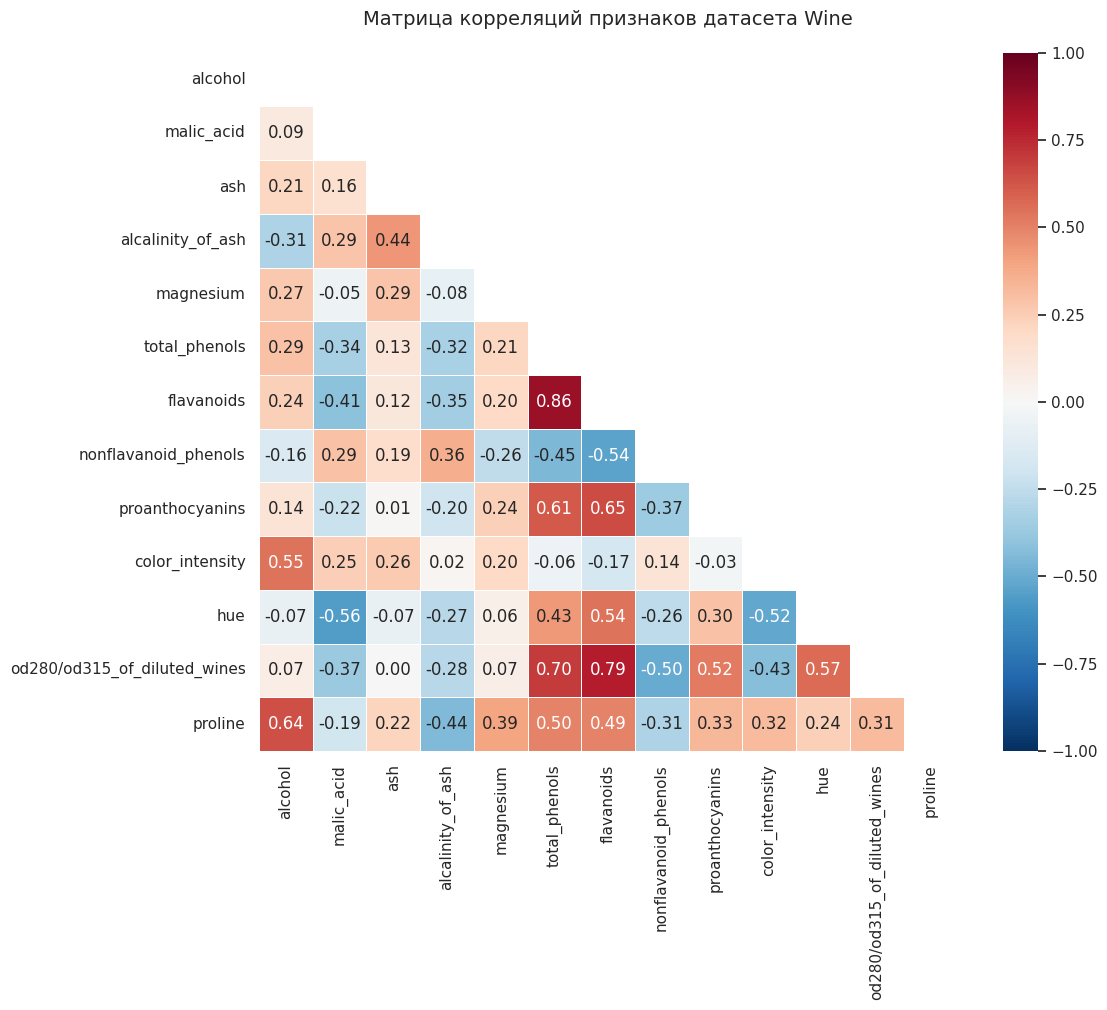

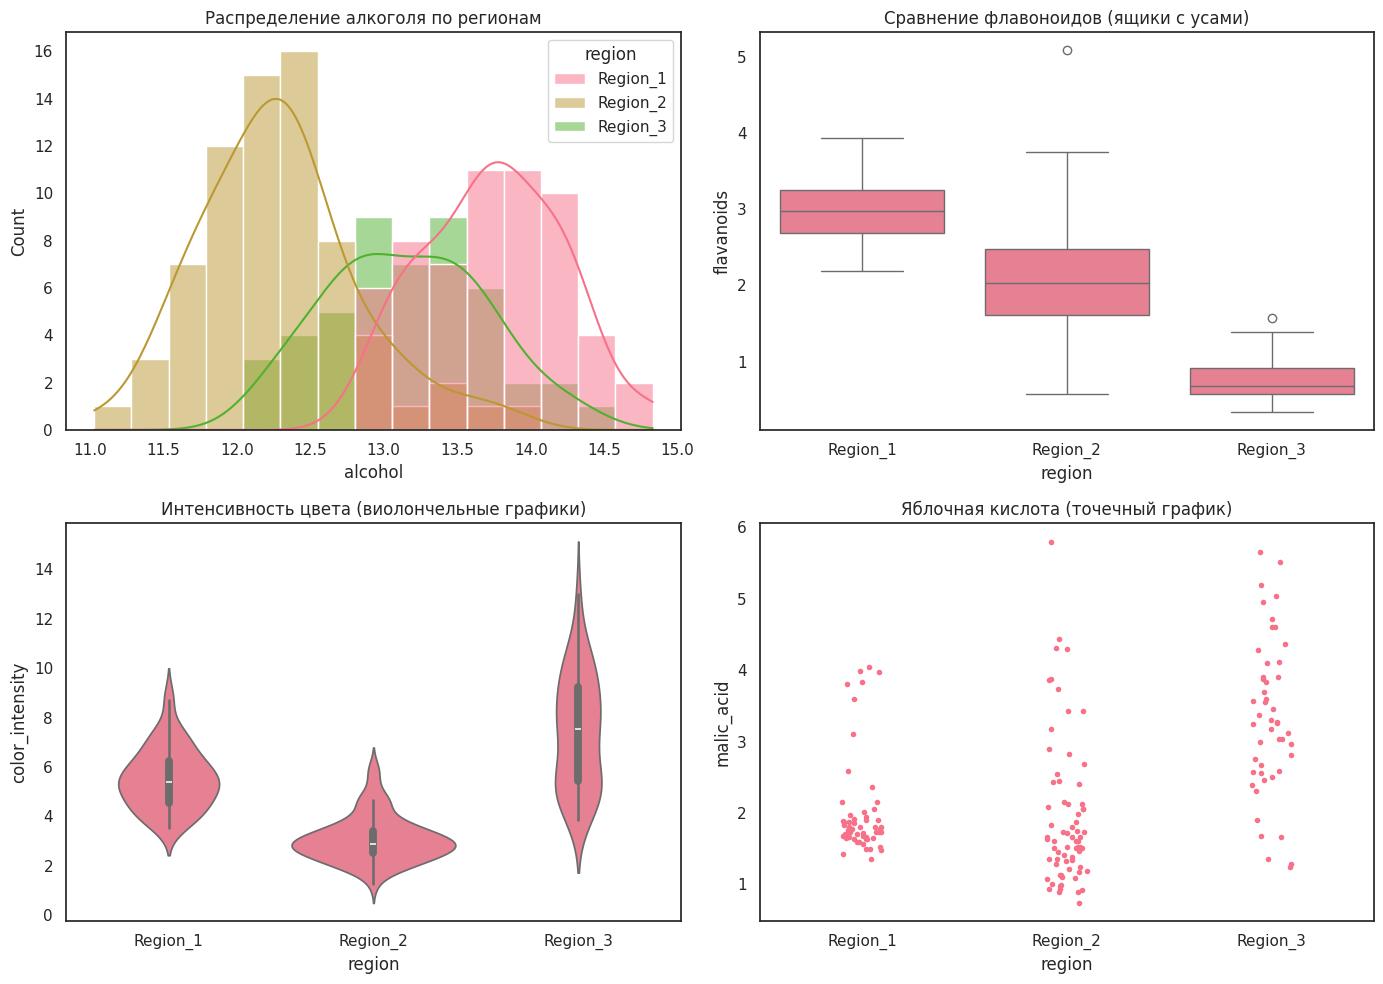


✓ Матрица признаков X: (178, 13)
✓ Вектор меток y: (178,)
✓ Баланс классов: [59 71 48]


In [ ]:
# ========================================
# ШАГ 1: Настройка воспроизводимости
# ========================================
import numpy as np
np.random.seed(42)  # Фиксируем случайность ДО всех операций

# ========================================
# ШАГ 2: Загрузка данных и преобразование
# ========================================
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['region'] = pd.Categorical.from_codes(wine.target, [f'Region_{i+1}' for i in range(3)])

print("✓ Данные загружены. Форма:", df.shape)
print("\nПервые 3 строки:")
display(df.head(3))

# ========================================
# ШАГ 3: Анализ структуры и статистики
# ========================================
print("\n=== Типы данных и пропуски ===")
print(df.info())

print("\n=== Описательная статистика (первые 5 признаков) ===")
display(df.iloc[:, :5].describe().round(2))

# ========================================
# ШАГ 4: Визуализация корреляций
# ========================================
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="white", palette="husl")

# Тепловая карта корреляций (только для признаков)
plt.figure(figsize=(12, 10))
corr_matrix = df.iloc[:, :-2].corr()  # Исключаем target и region
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Скрываем верхний треугольник
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
plt.title('Матрица корреляций признаков датасета Wine', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# ========================================
# ШАГ 5: Анализ распределений ключевых признаков
# ========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Алкоголь
sns.histplot(data=df, x='alcohol', hue='region', kde=True, ax=axes[0, 0], bins=15)
axes[0, 0].set_title('Распределение алкоголя по регионам')

# Флавоноиды
sns.boxplot(data=df, x='region', y='flavanoids', ax=axes[0, 1])
axes[0, 1].set_title('Сравнение флавоноидов (ящики с усами)')

# Интенсивность цвета
sns.violinplot(data=df, x='region', y='color_intensity', ax=axes[1, 0])
axes[1, 0].set_title('Интенсивность цвета (виолончельные графики)')

# Яблочная кислота
sns.stripplot(data=df, x='region', y='malic_acid', ax=axes[1, 1], jitter=True, size=4)
axes[1, 1].set_title('Яблочная кислота (точечный график)')

plt.tight_layout()
plt.show()

# ========================================
# ШАГ 6: Разделение на признаки и целевую переменную
# ========================================
X = df.drop(['target', 'region'], axis=1).values
y = df['target'].values

print(f"\n✓ Матрица признаков X: {X.shape}")
print(f"✓ Вектор меток y: {y.shape}")
print(f"✓ Баланс классов: {np.bincount(y)}")  # Сколько образцов в каждом регионе

#Выявление мультиколлинеарности

In [8]:
# Часть кода взята с сайта:
# https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/

# Исключаем 'target' и 'region' из корреляционной матрицы, так как они не признаки.
# Корреляционная матрица уже была рассчитана в ШАГ 4 как `corr_matrix`

# Получаем верхний треугольник корреляционной матрицы, чтобы избежать дубликатов и самокорреляций
# (маска `mask` уже создана в ШАГ 4)

# Преобразуем корреляционную матрицу в numpy массив для удобства итерации
corr_values = corr_matrix.values
feature_names = corr_matrix.columns

strong_correlations = []

for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):  # Начинаем с i+1 для верхнего треугольника
        feature1 = feature_names[i]
        feature2 = feature_names[j]
        correlation = corr_values[i, j]

        if abs(correlation) > 0.7:
            strong_correlations.append({
                'Признак_1': feature1,
                'Признак_2': feature2,
                'Корреляция': correlation
            })

# Создаем DataFrame из найденных сильных корреляций
multicollinearity_df = pd.DataFrame(strong_correlations)

print(f"\n Найдено {len(multicollinearity_df)} пар признаков с абсолютной корреляцией > 0.7:")
display(multicollinearity_df.round(3))

# Подсчитываем, какой признак участвует в наибольшем числе сильных корреляций
correlated_features = list(multicollinearity_df['Признак_1']) + list(multicollinearity_df['Признак_2'])
feature_counts = pd.Series(correlated_features).value_counts()

if not feature_counts.empty:
    most_correlated_feature = feature_counts.index[0]
    max_correlations = feature_counts.iloc[0]
    print(f"\n Признак, участвующий в наибольшем числе сильных корреляций: '{most_correlated_feature}' ({max_correlations} раз).")
else:
    print("\n Нет признаков, участвующих в сильных корреляциях (ни одной пары не найдено).")


 Найдено 2 пар признаков с абсолютной корреляцией > 0.7:


,Признак_1,Признак_2,Корреляция
0,total_phenols,flavanoids,0.865
1,flavanoids,od280/od315_of_diluted_wines,0.787



 Признак, участвующий в наибольшем числе сильных корреляций: 'flavanoids' (2 раз).


In [13]:
# Код частично взят из статьи хабра.
# https://habr.com/ru/articles/556042/

from scipy.stats import skew
import pandas as pd

# Выбираем только числовые признаки для расчета асимметрии
# Исключаем 'target' и 'region', так как они являются целевой переменной и
# категориальным признаком, а не числовыми признаками для анализа распределения
numerical_features = df.drop(['target', 'region'], axis=1)

# Рассчитываем коэффициент асимметрии для каждого признака
skewness = numerical_features.apply(lambda x: skew(x))

print("Коэффициенты асимметрии для признаков:")
print(skewness.round(3))

# Находим 3 признака с наибольшей положительной асимметрией
top_3_positive_skew = skewness.sort_values(ascending=False).head(3)

print("\nТоп-3 признака с наибольшей положительной асимметрией:")
print(top_3_positive_skew.round(3))

Коэффициенты асимметрии для признаков:
alcohol                        -0.051
malic_acid                      1.031
ash                            -0.175
alcalinity_of_ash               0.211
magnesium                       1.089
total_phenols                   0.086
flavanoids                      0.025
nonflavanoid_phenols            0.446
proanthocyanins                 0.513
color_intensity                 0.861
hue                             0.021
od280/od315_of_diluted_wines   -0.305
proline                         0.761
dtype: float64

Топ-3 признака с наибольшей положительной асимметрией:
magnesium          1.089
malic_acid         1.031
color_intensity    0.861
dtype: float64


Асимметрией называется смещение распределения относительно ее моды. Отрицательная асимметрия, или левое смещение кривой, указывает на то, что площадь под графиком больше на левой стороне моды. Положительная асимметрия, или правое смещение кривой, указывает на то, что площадь под графиком больше на правой стороне моды.

✓ Новый признак 'wine_quality_index' создан.


/tmp/ipykernel_226/388563828.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='region', y='wine_quality_index', palette='viridis')


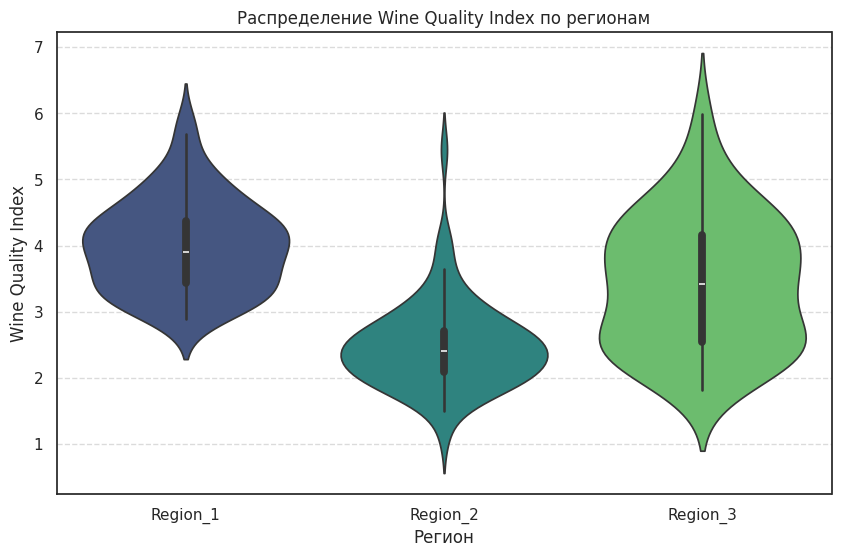


Коэффициенты разделения для 'wine_quality_index':
  wine_quality_index_Region_1_vs_Region_2: 1.124
  wine_quality_index_Region_1_vs_Region_3: 0.339
  wine_quality_index_Region_2_vs_Region_3: 0.568

Коэффициенты разделения для 'flavanoids':
  flavanoids_Region_1_vs_Region_2: 0.817
  flavanoids_Region_1_vs_Region_3: 3.185
  flavanoids_Region_2_vs_Region_3: 1.300

Коэффициенты разделения для 'color_intensity':
  color_intensity_Region_1_vs_Region_2: 1.129
  color_intensity_Region_1_vs_Region_3: 0.526
  color_intensity_Region_2_vs_Region_3: 1.332

=== Сравнение коэффициентов разделения ===
Пара регионов: Region_1_vs_Region_2
  wine_quality_index: 1.124
  flavanoids:         0.817
  color_intensity:    1.129
  -> Wine Quality Index не демонстрирует лучшего разделения для этой пары (или один из исходных признаков лучше).

Пара регионов: Region_1_vs_Region_3
  wine_quality_index: 0.339
  flavanoids:         3.185
  color_intensity:    0.526
  -> Wine Quality Index не демонстрирует лучшего ра

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Сконструируйте новый признак
df['wine_quality_index'] = 0.6 * df['flavanoids'] + 0.4 * df['color_intensity']

print("✓ Новый признак 'wine_quality_index' создан.")

# 2. Постройте график распределения этого индекса по регионам
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='region', y='wine_quality_index', palette='viridis')
plt.title('Распределение Wine Quality Index по регионам')
plt.xlabel('Регион')
plt.ylabel('Wine Quality Index')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Подтвердите вывод количественно через расчёт коэффициента разделения классов

def calculate_separation(feature_name, dataframe):
    separation_scores = {}
    regions = dataframe['region'].unique()

    # Итерируем по всем уникальным парам регионов
    for i in range(len(regions)):
        for j in range(i + 1, len(regions)):
            region1 = regions[i]
            region2 = regions[j]

            data1 = dataframe[dataframe['region'] == region1][feature_name]
            data2 = dataframe[dataframe['region'] == region2][feature_name]

            mean_class1 = data1.mean()
            mean_class2 = data2.mean()
            std_class1 = data1.std()
            std_class2 = data2.std()

            # Избегаем деления на ноль, если стандартное отклонение равно 0
            if (std_class1 + std_class2) == 0:
                separation = np.inf if mean_class1 != mean_class2 else 0
            else:
                separation = abs(mean_class1 - mean_class2) / (std_class1 + std_class2)

            separation_scores[f'{feature_name}_{region1}_vs_{region2}'] = separation

    return separation_scores

# Рассчитываем коэффициент разделения для нового признака
separation_new_feature = calculate_separation('wine_quality_index', df)
print("\nКоэффициенты разделения для 'wine_quality_index':")
for k, v in separation_new_feature.items():
    print(f"  {k}: {v:.3f}")

# Рассчитываем коэффициент разделения для исходных признаков
separation_flavanoids = calculate_separation('flavanoids', df)
print("\nКоэффициенты разделения для 'flavanoids':")
for k, v in separation_flavanoids.items():
    print(f"  {k}: {v:.3f}")

separation_color_intensity = calculate_separation('color_intensity', df)
print("\nКоэффициенты разделения для 'color_intensity':")
for k, v in separation_color_intensity.items():
    print(f"  {k}: {v:.3f}")

# Сравнение и вывод
print("\n=== Сравнение коэффициентов разделения ===")
for region_pair_key in separation_new_feature.keys():
    print(f"Пара регионов: {region_pair_key.replace('wine_quality_index_', '')}")
    print(f"  wine_quality_index: {separation_new_feature[region_pair_key]:.3f}")
    print(f"  flavanoids:         {separation_flavanoids[region_pair_key.replace('wine_quality_index', 'flavanoids')]:.3f}")
    print(f"  color_intensity:    {separation_color_intensity[region_pair_key.replace('wine_quality_index', 'color_intensity')]:.3f}")

    # Определяем, улучшился ли новый признак в этой паре
    new_is_better = separation_new_feature[region_pair_key] > separation_flavanoids[region_pair_key.replace('wine_quality_index', 'flavanoids')] and \
                    separation_new_feature[region_pair_key] > separation_color_intensity[region_pair_key.replace('wine_quality_index', 'color_intensity')]

    if new_is_better:
        print("  -> Wine Quality Index демонстрирует лучшее разделение для этой пары.\n")
    else:
        print("  -> Wine Quality Index не демонстрирует лучшего разделения для этой пары (или один из исходных признаков лучше).\n")


## Выводы по анализу датасета Wine

Датасет Wine содержит 13 числовых признаков, описывающих химический состав вина, и целевую переменную, представляющую один из трех регионов происхождения. Данные являются чистыми, без пропусков и готовы к анализу. Мы выявили сильную мультиколлинеарность между некоторыми признаками, а также определили признаки с выраженной асимметрией, что указывает на необходимость потенциальной предобработки для определенных моделей. Признаки 'flavanoids' и 'color_intensity' показали хорошее разделение классов, однако их простая линейная комбинация не улучшила эту способность.